In [25]:
import klayout.db as db
import numpy as np

# parameters
a=490 #lattice constant in nm
m=0.15 #shift in a
R=30 # Radius in a
core=3 # core radius in a
s=0.32 #triangle side size in a
w=-1 #vortex winding mod3==-1

ly = db.Layout()
# sets the database unit to 1 nm
ly.dbu = 0.001
# adds a single top cell
top_cell = ly.create_cell("SAMPLE")
# creates a new layer (layer number 1, datatype 0)
layer1 = ly.layer(1, 0)

a1=np.array([1/2,np.sqrt(3)/2])
a2=np.array([-1/2,np.sqrt(3)/2])
down=np.array([0,0])
up=np.array([0,-2*np.sqrt(3)/3])
down_list=[]
up_list=[]
down_list_coords=[]
down_list_site=[]
up_list_coords=[]

colors_list=[]
for i in range(-R,2*R+1):
    for j in range(-R,2*R+1):
        if np.linalg.norm(i*a1+j*a2+down)<0.8*R:
            phi0=((-i+j)%3)*2*np.pi/3
            if np.linalg.norm(i*a1+j*a2+down)<core:
                shift=np.array([0,0])
            else:
                r=i*a1+j*a2+down
                theta=np.arctan2(r[1],r[0])
                shift=np.array([np.cos(-w*theta+phi0),np.sin(-w*theta+phi0)])
            if ((i-j)%3)==0:
                colors_list.append('tab:red')
            elif ((i-j)%3)==1:
                colors_list.append('tab:blue')
            else:
                colors_list.append('tab:green')
            down_list.append(i*a1+j*a2+down+shift*m)
            down_list_coords.append([i,j])
            down_list_site.append(i*a1+j*a2+down)
        if np.linalg.norm(i*a1+j*a2+up)<0.8*R:
            up_list.append(i*a1+j*a2+up)
            up_list_coords.append([i,j])
down_list=np.array(down_list)
up_list=np.array(up_list)
down_list_site=np.array(down_list_site)

down_triangle=-s*a*np.array([[0,np.sqrt(3)/3],[-1/2,-np.sqrt(3)/6],[1/2,-np.sqrt(3)/6]])
up_triangle=s*a*np.array([[0,np.sqrt(3)/3],[-1/2,-np.sqrt(3)/6],[1/2,-np.sqrt(3)/6]])

for point in down_list:
   x=point[0]*a
   y=point[1]*a
   d0=db.DPoint(down_triangle.flatten()[0],down_triangle.flatten()[1])
   d1=db.DPoint(down_triangle.flatten()[2],down_triangle.flatten()[3])
   d2=db.DPoint(down_triangle.flatten()[4],down_triangle.flatten()[5])
   tri = db.DPolygon([d0,d1,d2]).moved(x,y)
   top_cell.shapes(layer1).insert(tri)

for point in up_list:
   x=point[0]*a
   y=point[1]*a
   d0=db.DPoint(up_triangle.flatten()[0],up_triangle.flatten()[1])
   d1=db.DPoint(up_triangle.flatten()[2],up_triangle.flatten()[3])
   d2=db.DPoint(up_triangle.flatten()[4],up_triangle.flatten()[5])
   tri = db.DPolygon([d0,d1,d2]).moved(x,y)
   top_cell.shapes(layer1).insert(tri)

# adds an envelope box on layer 2/0
layer2 = ly.layer(2, 0)
envelope = top_cell.dbbox().enlarged(2*R*a, 2*R*a)
top_cell.shapes(layer2).insert(envelope)
  
# writes the layout to GDS
ly.write("basic.gds")

In [23]:
import klayout.db as db

ly = db.Layout()

# sets the database unit to 1 nm
ly.dbu = 0.001

# adds a single top cell
top_cell = ly.create_cell("SAMPLE")

# creates a new layer (layer number 1, datatype 0)
layer1 = ly.layer(1, 0)

pattern = """
.#...#.#......###..#...#..###..#...#.#####
.#..#..#.....#...#.#...#.#...#.#...#...#..
.#.#...#.....#...#.#...#.#...#.#...#...#..
.##....#.....#####..#.# .#...#.#...#...#..
.#.#...#.....#...#...#. .#...#.#...#...#..
.#..#..#.....#...#...#. .#...#.#...#...#..
.#...#.#####.#...#...#. ..###...###....#..
"""

# produces pixels from the bitmap as 0.5x0.5 µm
# boxes on a 1x1 µm grid:
y = 8.0
for line in pattern.split("\n"):

  x = 0.0
  for bit in line:

    if bit == "#":
      # creates a rectangle for the "on" pixel
      rect = db.DBox(0, 0, 0.5, 0.5).moved(x, y)
      top_cell.shapes(layer1).insert(rect)

    x += 1.0

  y -= 1.0

# adds an envelope box on layer 2/0
layer2 = ly.layer(2, 0)
envelope = top_cell.dbbox().enlarged(1.0, 1.0)
top_cell.shapes(layer2).insert(envelope)
  
# writes the layout to GDS
ly.write("basic.gds")

[]

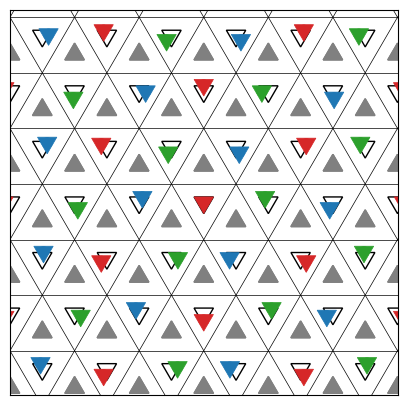

In [24]:
import numpy as np
import matplotlib.pyplot as plt
a1=np.array([1/2,np.sqrt(3)/2])
a2=np.array([-1/2,np.sqrt(3)/2])
down=np.array([0,0])
up=np.array([0,-2*np.sqrt(3)/3])
down_list=[]
up_list=[]
down_list_coords=[]
down_list_site=[]
up_list_coords=[]
m=0.1
R=10
core=0.7
s=0.3
w=-1
colors_list=[]
for i in range(-R,2*R+1):
    for j in range(-R,2*R+1):
        if np.linalg.norm(i*a1+j*a2+down)<0.8*R:
            phi0=((-i+j)%3)*2*np.pi/3
            if np.linalg.norm(i*a1+j*a2+down)<core:
                shift=np.array([0,0])
            else:
                r=i*a1+j*a2+down
                theta=np.arctan2(r[1],r[0])
                shift=np.array([np.cos(-w*theta+phi0),np.sin(-w*theta+phi0)])
            if ((i-j)%3)==0:
                colors_list.append('tab:red')
            elif ((i-j)%3)==1:
                colors_list.append('tab:blue')
            else:
                colors_list.append('tab:green')
            down_list.append(i*a1+j*a2+down+shift*m)
            down_list_coords.append([i,j])
            down_list_site.append(i*a1+j*a2+down)
            up_list.append(i*a1+j*a2+up)
            up_list_coords.append([i,j])
down_list=np.array(down_list)
up_list=np.array(up_list)
down_list_site=np.array(down_list_site)


fig,ax = plt.subplots(figsize=(5,5))
down_triangle=-s*np.array([[0,np.sqrt(3)/3],[-1/2,-np.sqrt(3)/6],[1/2,-np.sqrt(3)/6]])

for site in down_list_site:
    tri=plt.Polygon(down_triangle+site,color="black",fill=False)
    ax.add_patch(tri)
ax.scatter(down_list[:,0],down_list[:,1],marker='o',s=50,color=colors_list)
up_triangle=s*np.array([[0,np.sqrt(3)/3],[-1/2,-np.sqrt(3)/6],[1/2,-np.sqrt(3)/6]])
for i in range(down_list.shape[0]):
    tri=plt.Polygon(down_triangle+down_list[i],color=colors_list[i],fill=True,linewidth=0.5)
    ax.add_patch(tri)
for site in up_list:
    tri=plt.Polygon(up_triangle+site,color="grey")
    ax.add_patch(tri)
    ax.add_patch(tri)
lattice_center=(up+down)/2
for i in range(-R,2*R+1):
    ax.plot([i*a1[0]+(-R)*a2[0]+lattice_center[0],i*a1[0]+(R+1-i)*a2[0]+lattice_center[0]],[i*a1[1]+(-R)*a2[1]+lattice_center[1],i*a1[1]+(R+1-i)*a2[1]+lattice_center[1]],color='black',linewidth=0.5)
for j in range(-R,2*R+1):
    ax.plot([(-R)*a1[0]+j*a2[0]+lattice_center[0],(R+1-j)*a1[0]+j*a2[0]+lattice_center[0]],[(-R)*a1[1]+j*a2[1]+lattice_center[1],(R+1-j)*a1[1]+j*a2[1]+lattice_center[1]],color='black',linewidth=0.5)
for k in range(-R+1,2*R+2):
    ax.plot([(k)*a1[0]+(-R)*a2[0]+lattice_center[0],(-R)*a1[0]+k*a2[0]+lattice_center[0]],[(k)*a1[1]+(-R)*a2[1]+lattice_center[1],(-R)*a1[1]+k*a2[1]+lattice_center[1]],color='black',linewidth=0.5)
#ax.set_xlim(-R-1,R+1)
#ax.set_ylim(-R-1,R+1)
ax.set_xlim(-3,3)
ax.set_ylim(-3,3)
ax.set_xticks([])
ax.set_yticks([])